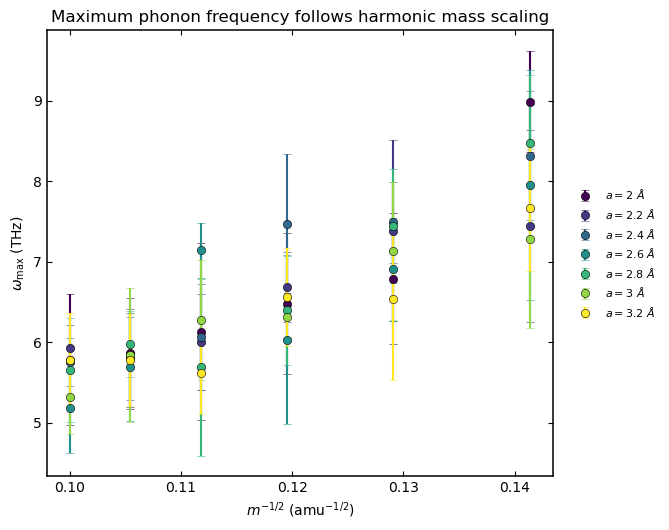

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PKL_DIR = Path("./dataframes/")
DATAFRAME_FILES = {
    "dataframe000013": PKL_DIR / "dataframe000013.pkl",
    "dataframe000014": PKL_DIR / "dataframe000014.pkl",
    "dataframe000015": PKL_DIR / "dataframe000015.pkl",
    "dataframe000016": PKL_DIR / "dataframe000016.pkl",
}

TOP_K = 5
RANK_BY = "fitness_norm"
OUTPUT_DIR = Path("mass_scaling_omega_max")
OUTPUT_DIR.mkdir(exist_ok=True)

def find_first_existing(candidates, columns):
    return next((c for c in candidates if c in columns), None)

frames = []
for label, path in DATAFRAME_FILES.items():
    df = pd.read_pickle(path).copy()
    df["dataset"] = label
    frames.append(df)

df_all = pd.concat(frames, ignore_index=True)

mass_col = find_first_existing(["mass", "m"], df_all.columns)
alat_col = find_first_existing(["a_val", "alat", "a_latt", "lattice_parameter"], df_all.columns)
rank_col = find_first_existing([RANK_BY, "fitness_norm", "fnorm"], df_all.columns)
max_freq_col = find_first_existing(["max_frequency", "max_freq", "omega_max"], df_all.columns)

df = (
    df_all.sort_values(rank_col, ascending=False)
    .groupby(["dataset", mass_col, alat_col], group_keys=False)
    .head(TOP_K)
    .copy()
)

df["omega_max_THz"] = pd.to_numeric(df[max_freq_col], errors="coerce")
df[mass_col] = pd.to_numeric(df[mass_col], errors="coerce")
df[alat_col] = pd.to_numeric(df[alat_col], errors="coerce")
df = df.dropna(subset=["omega_max_THz", mass_col, alat_col])

agg = (
    df.groupby([alat_col, mass_col])
    .agg(
        omega_max_mean=("omega_max_THz", "mean"),
        omega_max_std=("omega_max_THz", "std"),
        n=("omega_max_THz", "size"),
    )
    .reset_index()
)

agg["omega_max_std"] = agg["omega_max_std"].fillna(0.0)
agg["mass_inv_sqrt"] = 1 / np.sqrt(agg[mass_col])

fig, ax = plt.subplots(figsize=(6.8, 5.4))

unique_a = np.array(sorted(agg[alat_col].unique()), dtype=float)
cmap = plt.get_cmap("viridis")
norm = plt.Normalize(unique_a.min(), unique_a.max())

for a_val in unique_a:
    sub = agg[np.isclose(agg[alat_col], a_val)].sort_values("mass_inv_sqrt")
    color = cmap(norm(a_val))

    ax.errorbar(
        sub["mass_inv_sqrt"],
        sub["omega_max_mean"],
        yerr=sub["omega_max_std"],
        fmt="o",
        capsize=3,
        color=color,
        markeredgecolor="black",
        markeredgewidth=0.4,
        label=fr"$a={a_val:g}$ $\AA$",
    )

    x = sub["mass_inv_sqrt"].to_numpy()
    y = sub["omega_max_mean"].to_numpy()
    coeff = np.polyfit(x, y, 1)
    xfit = np.linspace(x.min(), x.max(), 100)
    #ax.plot(xfit, np.polyval(coeff, xfit), color=color, linewidth=1.2)

ax.set_xlabel(r"$m^{-1/2}$ (amu$^{-1/2}$)")
ax.set_ylabel(r"$\omega_{\max}$ (THz)")
ax.set_title(r"Maximum phonon frequency follows harmonic mass scaling")

ax.tick_params(axis="both", which="both", direction="in", top=True, right=True)

for spine in ax.spines.values():
    spine.set_linewidth(1.1)

ax.legend(frameon=False, fontsize=8, bbox_to_anchor=(1.02, 0.5), loc="center left")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "omega_max_vs_mass_inv_sqrt_by_lattice_parameter.pdf", bbox_inches="tight", dpi=300)
fig.savefig(OUTPUT_DIR / "omega_max_vs_mass_inv_sqrt_by_lattice_parameter.png", bbox_inches="tight", dpi=300)

plt.show()

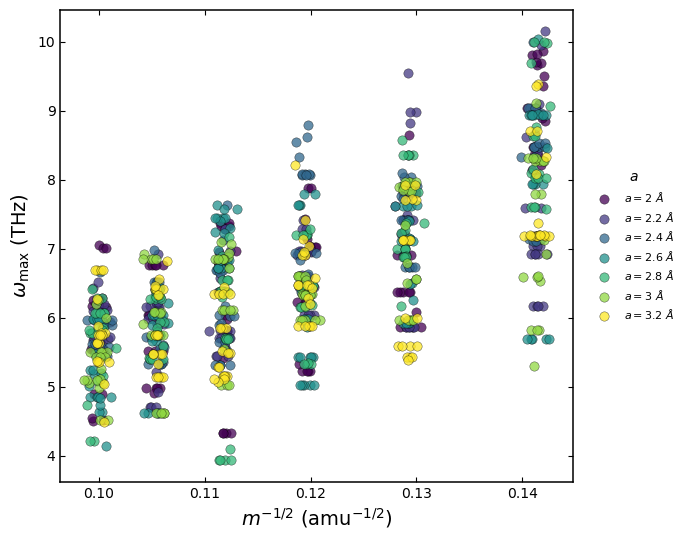

In [4]:
# ------------------------------------------------------------------
# Add inverse square root mass coordinate
# ------------------------------------------------------------------

df["mass_inv_sqrt"] = 1 / np.sqrt(df[mass_col])

fig, ax = plt.subplots(figsize=(7.0, 5.5))

unique_a = np.array(sorted(df[alat_col].unique()), dtype=float)

cmap = plt.get_cmap("viridis")
norm = plt.Normalize(unique_a.min(), unique_a.max())

rng = np.random.default_rng(12345)

for a_val in unique_a:

    sub = df[np.isclose(df[alat_col], a_val)].copy()

    color = cmap(norm(a_val))

    # small horizontal jitter
    jitter = rng.normal(
        loc=0.0,
        scale=0.0005,
        size=len(sub)
    )

    ax.scatter(
        sub["mass_inv_sqrt"] + jitter,
        sub["omega_max_THz"],
        s=45,
        color=color,
        edgecolor="black",
        linewidth=0.3,
        alpha=0.75,
        label=fr"$a={a_val:g}$ $\AA$"
    )

ax.set_xlabel(r"$m^{-1/2}$ (amu$^{-1/2}$)", fontsize=14)
ax.set_ylabel(r"$\omega_{\max}$ (THz)", fontsize=14)

ax.tick_params(
    axis="both",
    which="both",
    direction="in",
    top=True,
    right=True
)

for spine in ax.spines.values():
    spine.set_linewidth(1.1)

ax.legend(
    frameon=False,
    fontsize=8,
    bbox_to_anchor=(1.02, 0.5),
    loc="center left",
    title=r"$a$"
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR / "omega_max_vs_mass_inv_sqrt_scatter.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

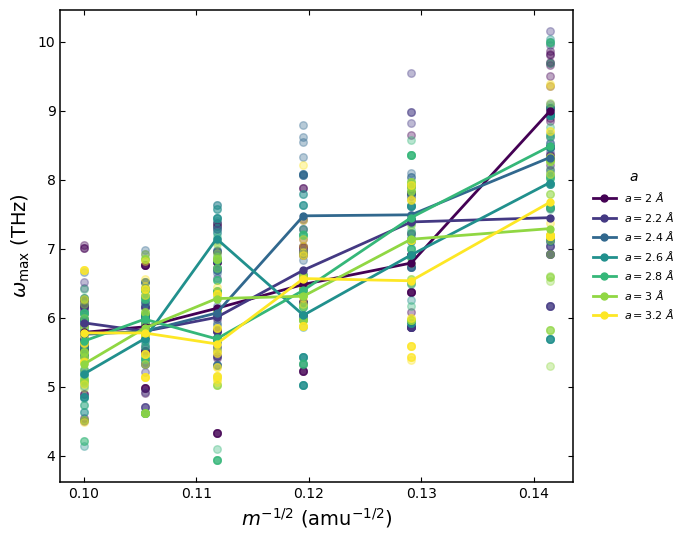

In [7]:
# ------------------------------------------------------------------
# Add inverse square root mass coordinate
# ------------------------------------------------------------------

df["mass_inv_sqrt"] = 1 / np.sqrt(df[mass_col])

fig, ax = plt.subplots(figsize=(7.0, 5.5))

unique_a = np.array(sorted(df[alat_col].unique()), dtype=float)

cmap = plt.get_cmap("viridis")
norm = plt.Normalize(unique_a.min(), unique_a.max())

rng = np.random.default_rng(12345)

for a_val in unique_a:

    sub = df[np.isclose(df[alat_col], a_val)]

    color = cmap(norm(a_val))

    # individual points
    ax.scatter(
        sub["mass_inv_sqrt"],
        sub["omega_max_THz"],
        s=30,
        alpha=0.35,
        color=color
    )

    # mean trend
    mean_sub = (
        sub.groupby(mass_col)["omega_max_THz"]
        .mean()
        .reset_index()
    )

    mean_sub["mass_inv_sqrt"] = 1 / np.sqrt(mean_sub[mass_col])

    ax.plot(
        mean_sub["mass_inv_sqrt"],
        mean_sub["omega_max_THz"],
        "-o",
        color=color,
        linewidth=2.0,
        markersize=5,
        label=fr"$a={a_val:g}$ $\AA$"
    )

ax.set_xlabel(r"$m^{-1/2}$ (amu$^{-1/2}$)", fontsize=14)
ax.set_ylabel(r"$\omega_{\max}$ (THz)", fontsize=14)

ax.tick_params(
    axis="both",
    which="both",
    direction="in",
    top=True,
    right=True
)

for spine in ax.spines.values():
    spine.set_linewidth(1.1)

ax.legend(
    frameon=False,
    fontsize=8,
    bbox_to_anchor=(1.02, 0.5),
    loc="center left",
    title=r"$a$"
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR / "omega_max_vs_mass_inv_sqrt_scatter.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()